In [2]:
import kagglehub
import os
from pathlib import Path
import matplotlib.pyplot as plt 
import random as rd

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\adamj.DESKTOP-RSU8KIQ\.cache\kagglehub\datasets\alessiocorrado99\animals10\versions\2


In [3]:
os.listdir(path)

['raw-img', 'translate.py']

In [4]:
raw_img = Path(path).joinpath("raw-img")
os.listdir(raw_img)

['cane',
 'cavallo',
 'elefante',
 'farfalla',
 'gallina',
 'gatto',
 'mucca',
 'pecora',
 'ragno',
 'scoiattolo']

In [5]:
raw_img_cats = os.listdir(Path(path).joinpath("raw-img").joinpath("gatto"))
raw_img_cats[-5:]

last_ten = raw_img_cats[-10:]
print(last_ten)

['nick-karvounis-538861-unsplash.jpg', 'OIP-BEqcWF77Te1ywfW1x-couAHaLG.jpeg', 'pacto-visual-199601-unsplash.jpg', 'paul-hanaoka-273394-unsplash.jpg', 'paul-hanaoka-280209-unsplash.jpg', 'q-aila-162475-unsplash.jpg', 'sam-burriss-378658-unsplash.jpg', 'sarah-dorweiler-128578-unsplash.jpg', 'xenia-bogarova-422041-unsplash.jpg', 'zoltan-tasi-437454-unsplash.jpg']


In [6]:
img_path = last_ten[9]
img_path

'zoltan-tasi-437454-unsplash.jpg'

nick-karvounis-538861-unsplash.jpg


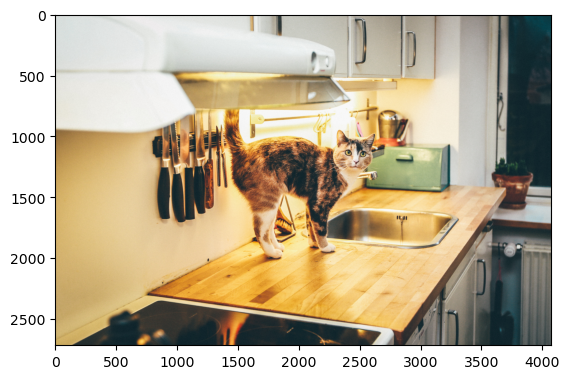

In [7]:
for i in range(1):
    print(last_ten[i])
    img = last_ten[i]
    plt.imshow(plt.imread(Path(path).joinpath("raw-img").joinpath("gatto").joinpath(img)))
    plt.show()

['sarah-dorweiler-128578-unsplash.jpg', 'xenia-bogarova-422041-unsplash.jpg', 'zoltan-tasi-437454-unsplash.jpg']
gatto


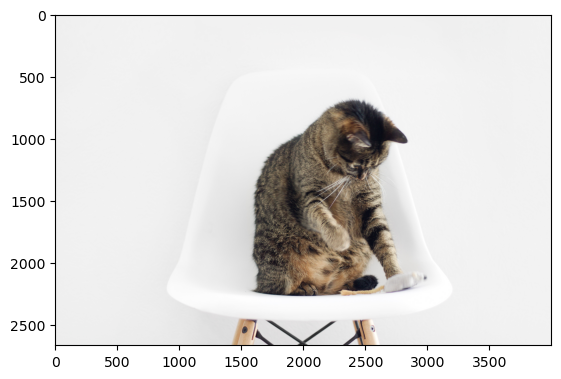

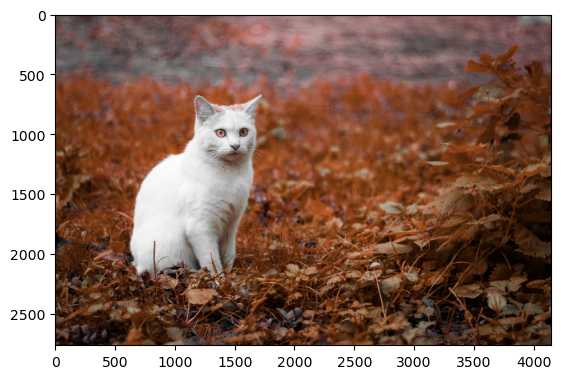

['OIP-_ZbJSvPHlAEP4YeyjtimhAHaJh.jpeg', 'OIP-_zMo5Tuf5UyDimOFh9gDMAHaHa.jpeg', 'OIP-__Yu1XH3iAC10OzGQFpC-AHaE8.jpeg']
cane


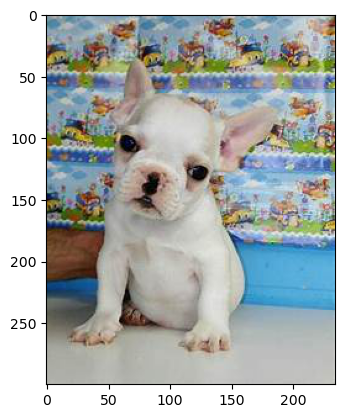

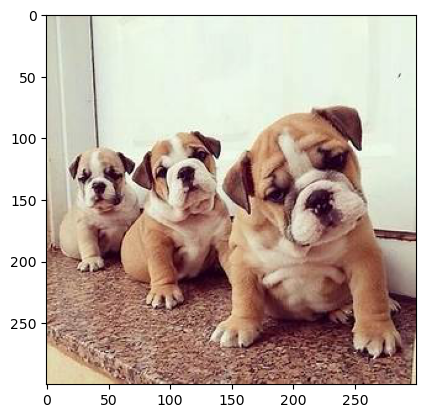

['OIP-_yOn1UTUWB7kWNmQOt93QAAAAA.jpeg', 'OIP-_z2ZnNHlWcjlKvdLpjxc2QHaC9.jpeg', 'OIP-_z8BmGoaFisnSQGFyl0QSgHaFj.jpeg']
farfalla


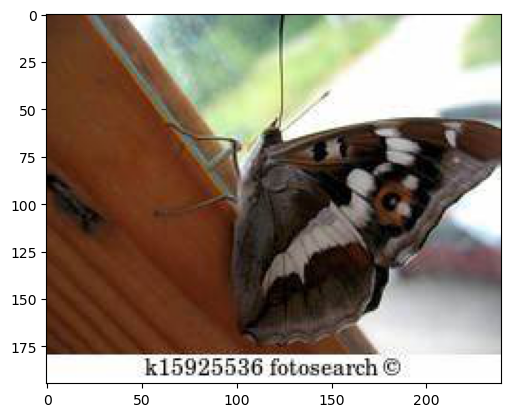

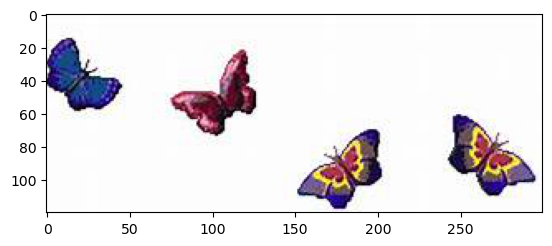

In [8]:
animals = ["gatto", "cane", "farfalla"]
for animal in animals:
    animal_path = Path(path).joinpath("raw-img").joinpath(animal)
    last = os.listdir(animal_path)[-3:]
    print(last)
    print(animal)
    for j in range (2):
        plt.imshow(plt.imread(animal_path.joinpath(last[j])))
        plt.show()

In [9]:
animal_list = os.listdir(raw_img)
animal_list
type(animal_list)
animal_list

['cane',
 'cavallo',
 'elefante',
 'farfalla',
 'gallina',
 'gatto',
 'mucca',
 'pecora',
 'ragno',
 'scoiattolo']

In [10]:
raw_img_path = Path(path).joinpath("raw-img")
for animal in animal_list:
    amount = len(os.listdir(raw_img_path.joinpath(animal)))
    print(f"{animal}:{amount}")

cane:4863
cavallo:2623
elefante:1446
farfalla:2112
gallina:3098
gatto:1668
mucca:1866
pecora:1820
ragno:4821
scoiattolo:1862


In [11]:
gattos = os.listdir(raw_img_path.joinpath("gatto"))
rd.shuffle(gattos)
split_point = int(len(gattos) * 0.8)
train = gattos[:split_point]
train
test = gattos[split_point:]
print(f"train {len(train)} test {len(test)} both {len(gattos)}")

train 1334 test 334 both 1668


In [12]:
my_dict = {}
train_pairs = []
val_pairs = []

for animal in animal_list:
    animal_file = os.listdir(raw_img_path.joinpath(animal))
    rd.shuffle(animal_file)
    split_point = int(len(animal_file)*0.8)
    train_animal = animal_file[:split_point]
    val_animal = animal_file[split_point:]
   
    my_dict[animal] = {
                    "train" : train_animal,
                    "val" : val_animal, 
                    "both" : animal_file
                    }

    for file in train_animal:
        full_path = raw_img_path.joinpath(animal, file)
        train_pairs.append((animal, full_path))
    for file in val_animal:
        full_path = raw_img_path.joinpath(animal, file)
        val_pairs.append((animal, full_path))

#    print(f"{animal} train {len(train_animal)} val {len(val_animal)} both {len(animal_file)}")
train_pairs[:5]
len(train_pairs) + len(val_pairs)


26179

In [48]:
label_map = {}
for idx, animal in enumerate(animal_list):
    label_map[animal] = idx
print(label_map)

reverse_label_map = {}  
for animal, idx in label_map.items():
    reverse_label_map[idx] = animal
print(reverse_label_map)

{'cane': 0, 'cavallo': 1, 'elefante': 2, 'farfalla': 3, 'gallina': 4, 'gatto': 5, 'mucca': 6, 'pecora': 7, 'ragno': 8, 'scoiattolo': 9}
{0: 'cane', 1: 'cavallo', 2: 'elefante', 3: 'farfalla', 4: 'gallina', 5: 'gatto', 6: 'mucca', 7: 'pecora', 8: 'ragno', 9: 'scoiattolo'}


In [ ]:
train_encoded = []

for i in train_pairs:
    label_mapped = label_map[i[0]]
    train_encoded.append((i[1], label_mapped))

train_encoded[1][1]

0

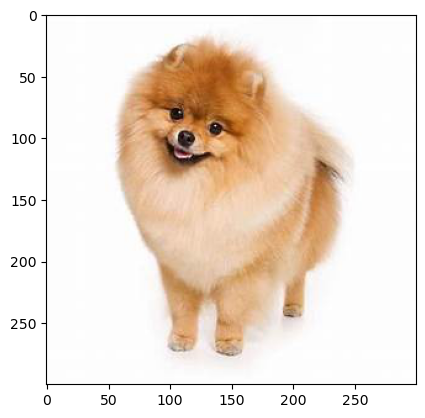

0 cane


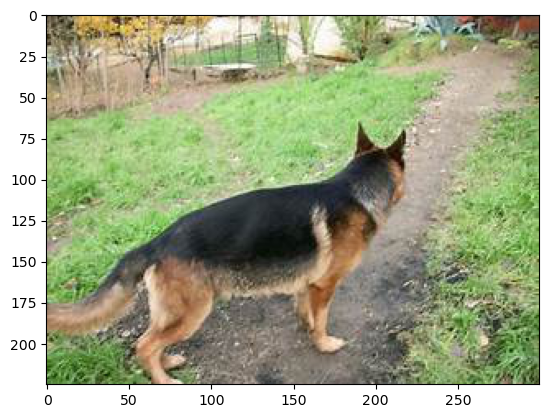

0 cane


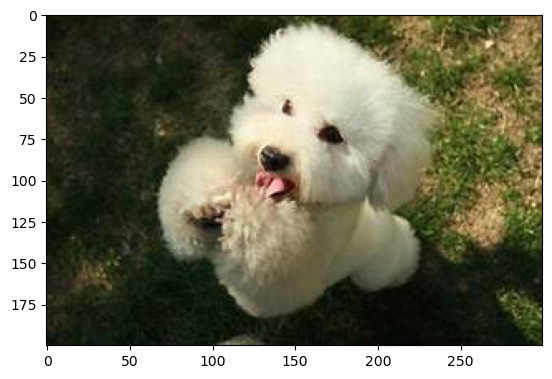

0 cane


In [50]:
for i in range(3):
    img = train_encoded[i][0]
    group = train_encoded[i][1]
    plt.imshow(plt.imread(img))
    plt.show()
    print(group, reverse_label_map[group])

In [84]:
import torchvision as tv
from torchvision import transforms
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

In [83]:
img = Image.open(train_encoded[0][0])
print(img)
print(img.size)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
img_transformed = transform(img)
print(img_transformed.shape)

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=300x300 at 0x12653769820>
(300, 300)
torch.Size([3, 224, 224])
